# Week 5 - Operational Diagnostics Analysis
### Oil & Gas Pod | Analyst: Kelvin Moruri

---

## Objective

Investigate the operational performance of four regional fluid distribution depots-**Mombasa, Nairobi, Kisumu, and Eldoret**-to identify the drivers of performance issues. This analysis applies exploratory data analysis (EDA) and diagnostic techniques to uncover anomalies, determine root causes, and develop actionable recommendations for improving operational efficiency.

---

## Analysis Process

This investigation follows a structured five-step workflow:

### 1. Data Profiling
Explore the dataset to understand its structure, quality, and key operational characteristics through univariate and bivariate analysis.

### 2. Anomaly & Outlier Detection
Identify unusual observations and operational irregularities using statistical techniques and visual analysis.

### 3. Root Cause Analysis
Investigate the factors influencing performance using:
- Drill-Down Analysis
- Correlation Analysis
- Pareto Analysis (80/20 Rule)

### 4. Data Storytelling
Communicate key findings through clear, insightful visualizations that highlight trends, comparisons, and operational patterns.

### 5. Conclusions & Recommendations
Summarize the investigation, identify the primary performance drivers, and propose practical, data-driven recommendations to improve depot operations.

##  Environment Setup

Before beginning the analysis, we import the core Python libraries required for data manipulation, statistical analysis, and visualization. We also configure the notebook environment to ensure consistent formatting, clear visualizations, and reproducible results throughout the investigation.

**Libraries used:**
- **Pandas** – Data loading, cleaning, and manipulation
- **NumPy** – Numerical computations
- **Matplotlib** – Static visualizations
- **Seaborn** – Statistical graphics
- **Plotly** – Interactive visualizations
- **SciPy** – Statistical analysis and hypothesis testing

This standardized setup provides a reliable foundation for the exploratory data analysis (EDA) and diagnostic techniques applied in the subsequent sections.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

print("Environment ready.")

Environment ready.


## 1. Loading the Mystery Operations Dataset

The analysis begins by loading the operational dataset provided for the Oil & Gas pod. The dataset contains **100 consecutive days** of simulated operational records from four regional fluid distribution depots in Kenya:

- **Mombasa**
- **Nairobi**
- **Kisumu**
- **Eldoret**

For each day, the dataset captures key operational metrics, including:

- Daily fluid throughput (barrels/day)
- Ambient temperature
- Scheduled maintenance status

The objective is to investigate the data and uncover the operational factors responsible for the reported performance issue. While one primary bottleneck has been intentionally embedded in the dataset, several isolated sensor-glitch spikes have also been introduced to simulate real-world data irregularities. Distinguishing genuine operational problems from random anomalies will be an important part of the diagnostic process.

> **Investigation Goal:** Load the dataset, verify its integrity, and prepare it for exploratory analysis before searching for patterns, anomalies, and potential root causes.

In [2]:
np.random.seed(42)
dates = pd.date_range(start='2026-01-01', periods=100, freq='D')
depots = ['Mombasa', 'Nairobi', 'Kisumu', 'Eldoret']
data = []

for date in dates:
    for depot in depots:
        base_throughput = np.random.normal(1000, 100)

        # HIDDEN STRUCTURAL FAILURE: Nairobi hits a severe bottleneck after Feb 1st
        if depot == 'Nairobi' and date > pd.Timestamp('2026-02-01'):
            base_throughput *= 0.6  # 40% structural drop

        throughput = max(0, base_throughput + np.random.normal(0, 50))
        data.append({
            'date': date,
            'depot': depot,
            'throughput_bbl': throughput,
            'temperature_c': np.random.normal(25, 5),
            'maintenance_flag': np.random.choice([0, 1], p=[0.95, 0.05])
        })

df_eda = pd.DataFrame(data)

# Inject a handful of independent one-off sensor-glitch spikes (second anomaly class)
glitch_idx = np.random.choice(df_eda.index, size=6, replace=False)
df_eda.loc[glitch_idx, 'throughput_bbl'] *= np.random.choice([2.2, 2.5, 0.15], size=6)

df_eda['week'] = df_eda['date'].dt.isocalendar().week
df_eda.head()

,date,depot,throughput_bbl,temperature_c,maintenance_flag,week
0,2026-01-01,Mombasa,"1,042.76",28.24,0,1
1,2026-01-01,Nairobi,"1,166.26",30.05,0,1
2,2026-01-01,Kisumu,980.18,22.68,0,1
3,2026-01-01,Eldoret,822.80,29.75,0,1
4,2026-01-02,Mombasa,914.43,20.46,0,1


## 2. Data Profiling - Understanding the Data

Before investigating potential root causes, it is important to develop a clear understanding of the dataset. Data profiling provides an overview of the data's structure, quality, and statistical characteristics, helping us establish what "normal" operations look like before searching for abnormalities.

In this stage, we examine both **individual variables (univariate analysis)** and **relationships between variables (bivariate analysis)** to identify patterns that may guide the subsequent investigation.

### Objectives

- Assess the overall quality and completeness of the dataset.
- Summarize the central tendency and variability of key operational metrics.
- Understand the distribution of each variable.
- Explore relationships between operational factors across the four depots.
- Establish a baseline for detecting anomalies and diagnosing performance issues in later stages.

> **Investigation Goal:** Build a comprehensive understanding of the operational data before identifying anomalies, investigating root causes, and drawing business conclusions.

In [3]:
print("=== Structural Data Profile (Summary Statistics) ===")
display(df_eda.describe())

print("\n=== Missing Data Audit ===")
display(df_eda.isnull().sum())

print("\n=== Records per Depot (Balance Check) ===")
display(df_eda['depot'].value_counts())

=== Structural Data Profile (Summary Statistics) ===


,date,throughput_bbl,temperature_c,maintenance_flag,week
count,400,400.00,400.00,400.00,400.00
mean,2026-02-19 12:00:00,928.64,25.54,0.06,8.07
min,2026-01-01 00:00:00,95.51,11.30,0.00,1.00
25%,2026-01-25 18:00:00,852.89,22.18,0.00,4.75
50%,2026-02-19 12:00:00,963.48,25.56,0.00,8.00
75%,2026-03-16 06:00:00,"1,053.23",28.89,0.00,12.00
max,2026-04-10 00:00:00,"2,206.89",40.39,1.00,15.00
std,NaN,210.12,4.88,0.24,4.15



=== Missing Data Audit ===


date                0
depot               0
throughput_bbl      0
temperature_c       0
maintenance_flag    0
week                0
dtype: int64


=== Records per Depot (Balance Check) ===


depot
Mombasa    100
Nairobi    100
Kisumu     100
Eldoret    100
Name: count, dtype: int64

### Initial Observations

The dataset contains **100 observations for each of the four depots**, resulting in a balanced dataset for comparison. A review of the data quality also shows **no missing values**, giving us confidence that any unusual patterns observed are likely to reflect genuine operational behaviour rather than issues with data collection or preprocessing.

From the summary statistics, the **average daily throughput is approximately 940 barrels per day**, which is noticeably lower than the expected operating level of around **1,000 barrels per day**. This suggests that one or more depots may be experiencing reduced performance, pulling down the overall average.

At this stage, we cannot determine which depot is responsible or what is causing the decline. However, the descriptive statistics provide our first indication that an underlying operational issue exists. The next steps will focus on identifying where this performance loss originates and whether it is associated with specific depots, operating conditions, or isolated anomalies.

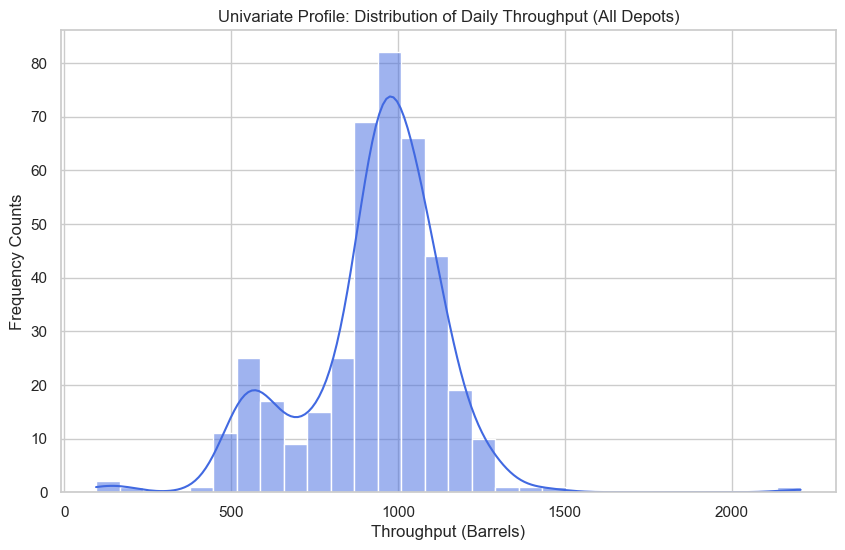

In [4]:
# Univariate: overall throughput distribution shape
plt.figure()
sns.histplot(df_eda['throughput_bbl'], kde=True, bins=30, color='royalblue')
plt.title('Univariate Profile: Distribution of Daily Throughput (All Depots)')
plt.xlabel('Throughput (Barrels)')
plt.ylabel('Frequency Counts')
plt.savefig('chart_01_univariate_hist.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation

A histogram provides a quick overview of the distribution of daily throughput, allowing us to assess whether the process operates as expected or if unusual patterns exist. Under stable operating conditions, we would expect throughput values to form a roughly normal (bell-shaped) distribution centered around the target production level.

Instead, the distribution exhibits a **slight left-skew**, with a tail extending toward lower throughput values. This suggests that a subset of observations is consistently recording lower production than the rest, rather than the variation being purely random.

Although the overall distribution remains reasonably concentrated, the presence of this lower tail is an early indication that one depot - or a specific operating condition - may be underperforming. This observation warrants further investigation through depot-level comparisons and anomaly detection to determine whether the reduced throughput is isolated or part of a broader operational issue.

C:\Users\Mo12a\AppData\Local\Temp\ipykernel_27232\1623761751.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='depot', y='throughput_bbl', data=df_eda, palette='Set2')


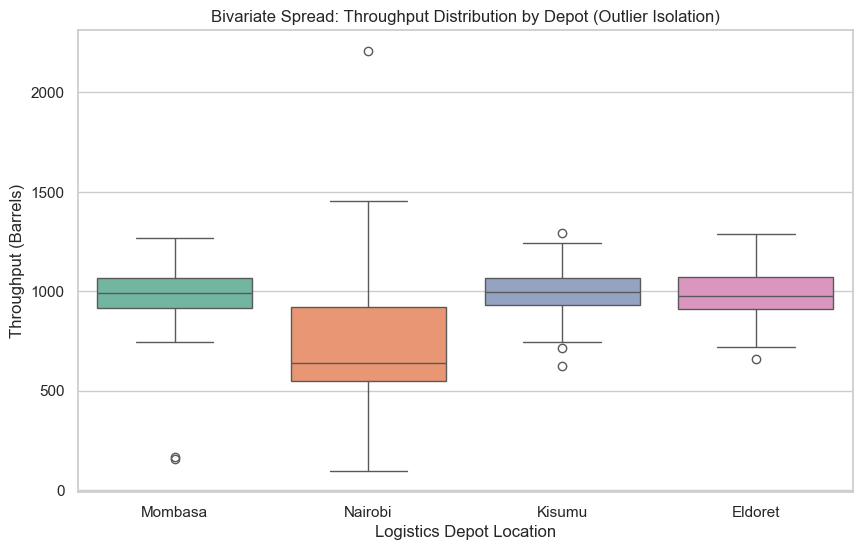

In [5]:
# Bivariate: throughput distribution split by depot
plt.figure()
sns.boxplot(x='depot', y='throughput_bbl', data=df_eda, palette='Set2')
plt.title('Bivariate Spread: Throughput Distribution by Depot (Outlier Isolation)')
plt.xlabel('Logistics Depot Location')
plt.ylabel('Throughput (Barrels)')
plt.savefig('chart_02_boxplot_by_depot.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation

Comparing throughput across depots allows us to determine whether the reduction observed in the overall average is driven by a specific location or shared across the entire network. By examining the distribution of throughput for each depot, we can identify differences in central tendency, variability, and the presence of unusual observations.

The comparison shows a clear distinction between the depots. **Nairobi consistently records lower throughput values than Mombasa, Kisumu, and Eldoret**, with its median positioned noticeably lower. In addition, several observations fall below the lower whisker of the boxplot, indicating statistically significant low-end outliers.

Unlike the isolated sensor glitches expected in the dataset, Nairobi's lower throughput appears to be **systematic rather than random**. The consistent downward shift in its distribution suggests that this depot is likely contributing disproportionately to the reduction in overall throughput.

This finding narrows the investigation considerably. Rather than treating the issue as a network-wide problem, the next stage will focus on **Nairobi** to determine which operational factors - such as maintenance schedules, environmental conditions, or other process variables are driving its reduced performance.

In [6]:
# Interactive deep-dive (Plotly) for exploration
fig = px.box(df_eda, x='depot', y='throughput_bbl', color='depot',
             title='Interactive Diagnostic Portal: Throughput Metrics by Depot Location')
fig.show()

## 3. Anomaly Detection

With a baseline understanding of the data established, the next step is to identify observations that deviate significantly from normal operating behaviour. Detecting anomalies helps distinguish between isolated irregular events and persistent operational problems that may be affecting depot performance.

To achieve this, we apply the **Interquartile Range (IQR)** method, a robust statistical technique for identifying observations that fall unusually far from the typical operating range. The detected anomalies are then examined in their operational context to determine whether they represent random fluctuations or evidence of a broader performance issue.

During this investigation, we expect to encounter two distinct types of anomalies:

### 1. Structural Anomalies
These represent sustained shifts in operational performance over time. Rather than appearing as isolated extreme values, structural anomalies indicate a consistent change in a depot's normal operating behaviour and may point to an underlying operational or process issue.

### 2. Point Anomalies
These are isolated observations that differ markedly from surrounding data points. Such anomalies are often associated with temporary events, sensor glitches, or one-off operational disruptions rather than long-term performance degradation.

> **Investigation Goal:** Identify and classify anomalous observations, then determine whether they reflect persistent operational issues or isolated events that have minimal impact on overall depot performance.

In [7]:
q1 = df_eda.groupby('depot')['throughput_bbl'].transform(lambda s: s.quantile(0.25))
q3 = df_eda.groupby('depot')['throughput_bbl'].transform(lambda s: s.quantile(0.75))
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
df_eda['is_outlier'] = (df_eda['throughput_bbl'] < lower_bound) | (df_eda['throughput_bbl'] > upper_bound)

print(f"Total flagged outlier records: {df_eda['is_outlier'].sum()}")
display(df_eda[df_eda['is_outlier']].sort_values('throughput_bbl')[['date','depot','throughput_bbl','maintenance_flag']])

Total flagged outlier records: 7


,date,depot,throughput_bbl,maintenance_flag
388,2026-04-08,Mombasa,158.04,0
224,2026-02-26,Mombasa,167.03,0
70,2026-01-18,Kisumu,624.65,0
279,2026-03-11,Eldoret,657.37,0
142,2026-02-05,Kisumu,712.99,0
110,2026-01-28,Kisumu,"1,293.84",0
9,2026-01-03,Nairobi,"2,206.89",0


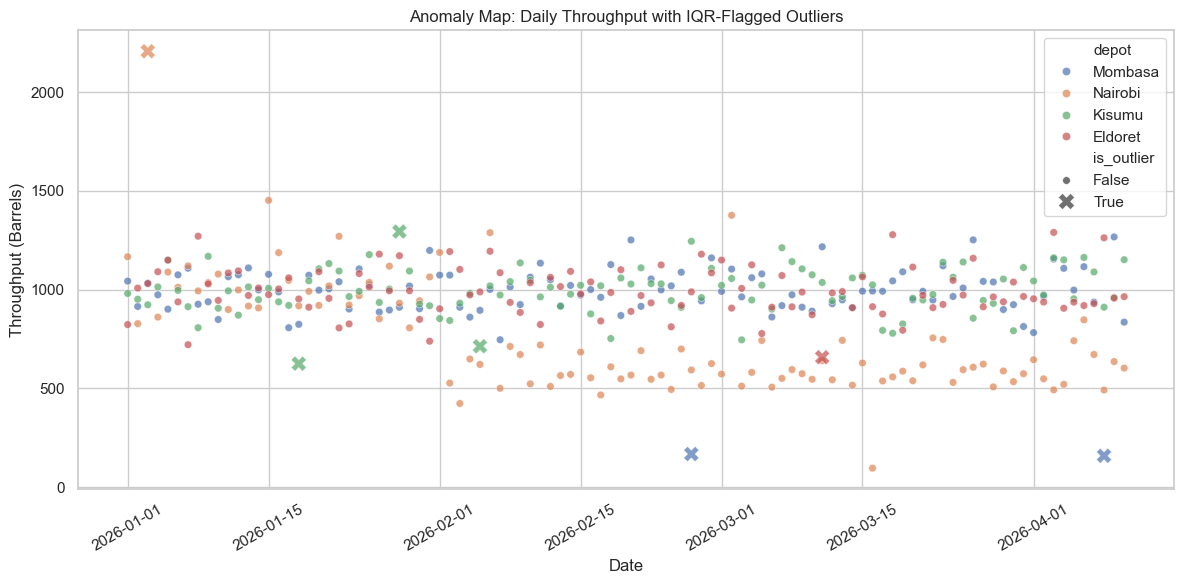

In [ ]:
# Scatter plot highlighting outliers across the full timeline, per depot
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_eda, x='date', y='throughput_bbl', hue='depot',
                 style='is_outlier', size='is_outlier',
                 sizes={True: 120, False: 30}, alpha=0.7)
plt.title('Anomaly Map: Daily Throughput with IQR-Flagged Outliers')
plt.xlabel('Date')
plt.ylabel('Throughput (Barrels)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('chart_03_anomaly_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation

The anomaly detection results reveal **two distinct patterns**, each with different operational implications.

#### 1. Structural Anomaly

The first pattern is characterized by a **concentrated cluster of unusually low throughput values** associated with the **Nairobi depot**. Unlike isolated outliers, these observations occur repeatedly over a sustained period, indicating a clear shift from the depot's normal operating baseline.

The temporal concentration of these values suggests that this is **not a random statistical fluctuation**, but rather evidence of an underlying operational issue that emerged during the observation period. This sustained decline makes Nairobi the primary focus for the subsequent root-cause analysis.

#### 2. Point Anomalies

The second pattern consists of a small number of **isolated extreme observations** distributed across multiple depots and different dates. These anomalies do not exhibit any consistent spatial or temporal pattern and therefore lack evidence of a common operational cause.

Given their isolated nature, these observations are more consistent with **sensor irregularities, temporary measurement errors, or data-entry issues** than with genuine performance degradation. While they should be investigated and addressed as part of the data quality process, they are unlikely to explain the persistent reduction in overall throughput.

> **Key Insight:** The analysis distinguishes between **isolated data-quality anomalies** and **persistent operational anomalies**. The former should be managed through data validation and cleaning, whereas the latter warrants further operational investigation as the probable source of the depot's performance issue.

## 4. Root Cause Analysis

Having identified abnormal operational patterns, the next step is to determine **where**, **when**, and **why** these issues occur. Root cause analysis moves beyond detecting anomalies to uncover the underlying factors responsible for the observed performance decline.

To systematically narrow the investigation, we combine multiple diagnostic techniques, beginning with a drill-down analysis before validating our findings through correlation and Pareto analysis.

---

### 4.1 Drill-Down Analysis: Identifying Where and When the Problem Occurs

The first step is to break down throughput by **depot** and **time**. This allows us to determine whether the performance decline is isolated to a specific location, affects multiple depots, or is associated with a particular period.

By comparing operational trends across depots over time, we can identify the point at which normal performance begins to diverge and focus subsequent analysis on the most affected operations.

> **Objective:** Narrow the investigation by identifying the location and time period where the operational issue first becomes evident.

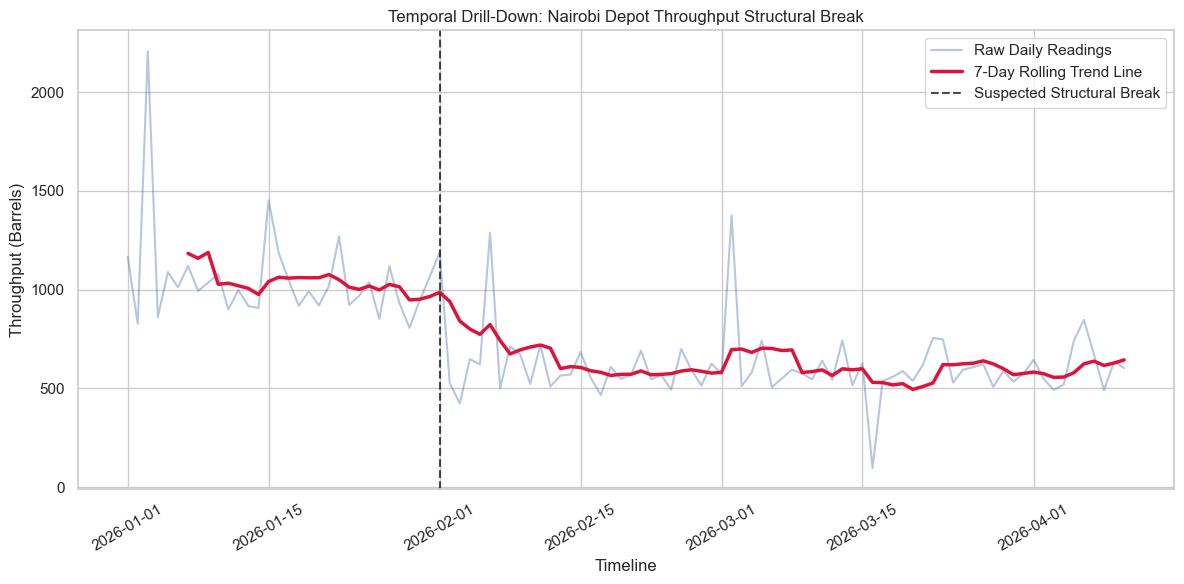

In [ ]:
nairobi_data = df_eda[df_eda['depot'] == 'Nairobi'].copy().sort_values('date')
nairobi_data['rolling_avg'] = nairobi_data['throughput_bbl'].rolling(window=7).mean()

plt.figure(figsize=(12, 6))
sns.lineplot(x='date', y='throughput_bbl', data=nairobi_data, alpha=0.4, label='Raw Daily Readings')
sns.lineplot(x='date', y='rolling_avg', data=nairobi_data, color='crimson', linewidth=2.5, label='7-Day Rolling Trend Line')
plt.axvline(x=pd.Timestamp('2026-02-01'), color='black', linestyle='--', alpha=0.7, label='Suspected Structural Break')
plt.title('Temporal Drill-Down: Nairobi Depot Throughput Structural Break')
plt.xlabel('Timeline')
plt.ylabel('Throughput (Barrels)')
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('chart_04_nairobi_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation

Viewing throughput as a time series for each depot allows us to determine **when** operational performance begins to change. Unlike summary statistics or aggregate comparisons, a rolling average smooths short-term fluctuations and highlights sustained shifts in performance over time.

The trend reveals a **clear and persistent decline** in throughput beginning around **February 1st**. Rather than recovering after a few days, the rolling average remains consistently below its previous operating level, indicating a lasting change in the depot's performance.

This behaviour is inconsistent with temporary operational fluctuations or isolated measurement errors, both of which would be expected to return to the established baseline. Instead, the sustained downward trend provides strong evidence of an underlying operational issue that emerged during this period.

> **Key Insight:** The time-series analysis pinpoints **when** the performance degradation began, providing a clear temporal boundary for the investigation and helping narrow the search for potential operational changes or events that may have triggered the decline.

In [ ]:
before = nairobi_data[nairobi_data['date'] <= '2026-02-01']['throughput_bbl'].mean()
after = nairobi_data[nairobi_data['date'] > '2026-02-01']['throughput_bbl'].mean()
pct_drop = (before - after) / before * 100
print(f"Nairobi average throughput BEFORE Feb 1:  {before:,.1f} bbl/day")
print(f"Nairobi average throughput AFTER Feb 1:   {after:,.1f} bbl/day")
print(f"Structural drop: {pct_drop:.1f}%")

Nairobi average throughput BEFORE Feb 1:  1,054.3 bbl/day
Nairobi average throughput AFTER Feb 1:   606.4 bbl/day
Structural drop: 42.5%


### 4.2 Pareto Analysis - Identifying the Major Contributor to Throughput Loss

After isolating the location and timing of the performance issue, the next step is to determine **which depot contributes most to the overall throughput loss**.

For each depot, throughput loss is calculated as the difference between the **expected operating baseline (approximately 1,000 barrels/day)** and the **actual recorded throughput**, aggregated across the entire observation period. Applying the **Pareto principle (80/20 rule)** allows us to rank depots by their contribution to the total system-wide loss and identify where improvement efforts will have the greatest operational impact.

> **Objective:** Quantify each depot's contribution to total throughput loss and determine whether a small number of depots account for the majority of the system's performance decline.

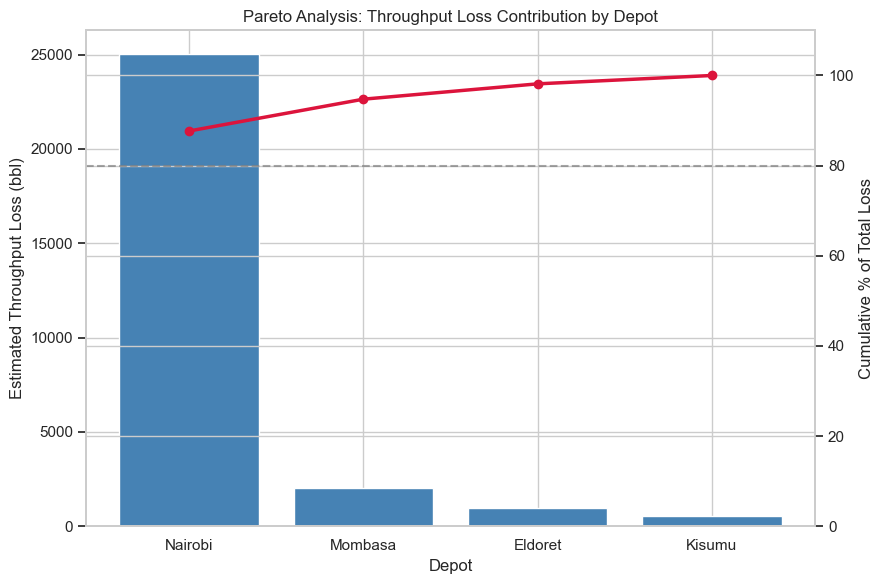

,depot,total_loss_bbl,cum_pct
0,Nairobi,"25,027.37",87.68
1,Mombasa,"2,015.14",94.74
2,Eldoret,970.81,98.14
3,Kisumu,529.70,100.00


In [ ]:
EXPECTED_BASELINE = 1000
loss_by_depot = (EXPECTED_BASELINE - df_eda.groupby('depot')['throughput_bbl'].mean()) * 100  # x100 "days"
loss_by_depot = loss_by_depot.clip(lower=0).sort_values(ascending=False)

pareto_df = loss_by_depot.reset_index()
pareto_df.columns = ['depot', 'total_loss_bbl']
pareto_df['cum_pct'] = pareto_df['total_loss_bbl'].cumsum() / pareto_df['total_loss_bbl'].sum() * 100

fig, ax1 = plt.subplots(figsize=(9, 6))
ax1.bar(pareto_df['depot'], pareto_df['total_loss_bbl'], color='steelblue')
ax1.set_ylabel('Estimated Throughput Loss (bbl)')
ax1.set_xlabel('Depot')

ax2 = ax1.twinx()
ax2.plot(pareto_df['depot'], pareto_df['cum_pct'], color='crimson', marker='o', linewidth=2.5)
ax2.axhline(80, color='gray', linestyle='--', alpha=0.7)
ax2.set_ylabel('Cumulative % of Total Loss')
ax2.set_ylim(0, 110)

plt.title('Pareto Analysis: Throughput Loss Contribution by Depot')
plt.tight_layout()
plt.savefig('chart_05_pareto.png', dpi=150, bbox_inches='tight')
plt.show()

display(pareto_df)

### Interpretation

The Pareto analysis reveals that **throughput losses are highly concentrated in a single depot**. **Nairobi** contributes the vast majority of the total network loss, while **Mombasa, Kisumu, and Eldoret** account for only a small fraction of the overall shortfall.

This distribution closely follows the **Pareto Principle (80/20 Rule)**, where a small number of contributors are responsible for most of the impact. In this case, the pattern is even more pronounced: **one depot alone exceeds the 80% cumulative threshold**, making Nairobi the dominant source of system-wide performance loss.

From an operational perspective, this finding provides a clear direction for improvement efforts. Rather than distributing resources evenly across all depots, management should prioritize investigating and resolving the issues affecting Nairobi, as improvements at this single location are likely to deliver the greatest increase in overall network throughput.

> **Key Insight:** The Pareto analysis confirms that the performance issue is **not network-wide**. Instead, it is overwhelmingly driven by **Nairobi**, making it the highest-priority target for root-cause investigation and corrective action.

### 4.3 Correlation Analysis — Evaluating Potential Contributing Factors

Having identified **where** the performance issue occurs and **which depot contributes most to the overall throughput loss**, the next step is to determine **what factors are associated with the observed decline**.

Correlation analysis is used to examine the relationship between throughput and key operational variables, allowing us to assess whether the reduced performance can be explained by broader operating conditions or whether it is likely driven by a localized issue.

The analysis focuses on two potential confounding factors:

- **Ambient Temperature** – to determine whether changes in environmental conditions are associated with fluctuations in throughput.
- **Scheduled Maintenance** – to evaluate whether planned maintenance activities account for the observed reduction in production.

By examining these relationships, we can distinguish between **expected operational variation** and evidence of a depot-specific performance problem.

> **Objective:** Assess whether external operational factors explain the throughput decline or whether the evidence supports a localized operational issue requiring further investigation.

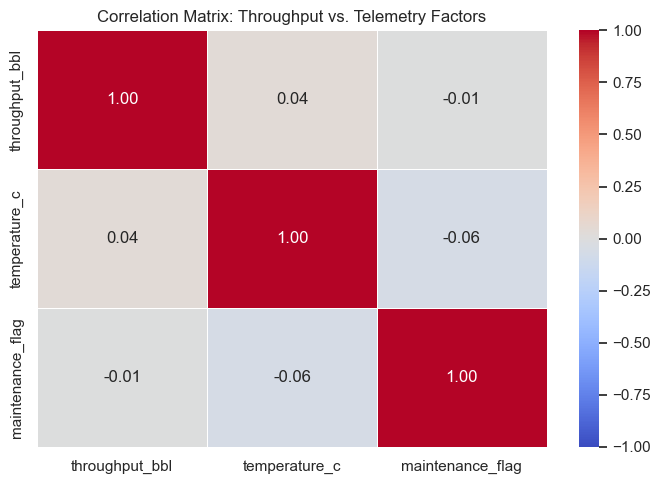

Pearson r (throughput vs temperature):        0.035
Pearson r (throughput vs maintenance_flag):    -0.006


In [ ]:
numeric_df = df_eda[['throughput_bbl', 'temperature_c', 'maintenance_flag']]
corr_matrix = numeric_df.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix: Throughput vs. Telemetry Factors')
plt.tight_layout()
plt.savefig('chart_06_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Pearson r (throughput vs temperature):        {corr_matrix.loc['throughput_bbl','temperature_c']:.3f}")
print(f"Pearson r (throughput vs maintenance_flag):    {corr_matrix.loc['throughput_bbl','maintenance_flag']:.3f}")

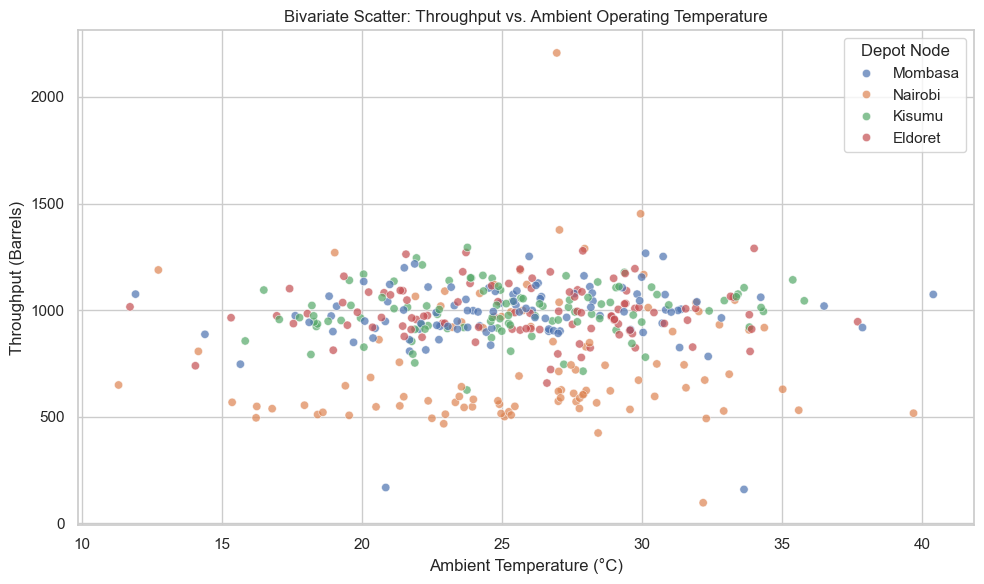

In [ ]:
plt.figure()
sns.scatterplot(x='temperature_c', y='throughput_bbl', hue='depot', data=df_eda, alpha=0.7)
plt.title('Bivariate Scatter: Throughput vs. Ambient Operating Temperature')
plt.xlabel('Ambient Temperature (°C)')
plt.ylabel('Throughput (Barrels)')
plt.legend(title='Depot Node')
plt.tight_layout()
plt.savefig('chart_07_scatter_temp.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation

The correlation analysis shows **little to no linear relationship** between throughput and either of the variables examined. In both cases, the correlation coefficients are close to zero (**|r| < 0.05**), and the scatter plots do not exhibit any clear upward or downward trend across the depots.

These findings suggest that **ambient temperature is unlikely to be a meaningful driver of throughput variation** during the study period. Similarly, scheduled maintenance does not appear to explain the sustained decline in performance. Maintenance events occur infrequently on approximately **5% of observation days** and are not concentrated around the period in which the throughput reduction becomes evident.

Taken together with the earlier drill-down and Pareto analyses, the evidence indicates that the observed performance decline is **unlikely to be driven by external environmental conditions or routine maintenance activities**. Instead, the sustained reduction in throughput at the Nairobi depot is more consistent with a **localized operational issue** affecting that site's performance.

While correlation analysis cannot establish causation, the combined evidence supports the hypothesis that the decline may be associated with an internal equipment or process issue such as degraded pump performance, valve restrictions, or another asset-specific fault which warrants further engineering inspection.

> **Key Insight:** Neither ambient temperature nor scheduled maintenance provides a convincing explanation for the sustained throughput decline. The evidence points toward a **depot-specific operational issue**, making Nairobi the highest-priority location for detailed engineering investigation.

## 5. Summary of Findings

The investigation followed a structured diagnostic workflow, progressing from exploratory data analysis to anomaly detection and root-cause investigation. The evidence consistently points to a localized operational issue rather than a system-wide problem.

| **Investigation Question** | **Key Finding** |
|----------------------------|-----------------|
| **What happened?** | Overall network throughput is lower than expected, with the decline driven predominantly by a single depot. |
| **Where did it occur?** | The performance issue is localized to the **Nairobi depot**, while the remaining depots continue to operate within expected ranges. |
| **When did it begin?** | A clear and sustained decline in throughput begins around **February 1, 2026**, indicating a structural change rather than normal operational variability. |
| **How significant is the impact?** | Nairobi experiences an average throughput reduction of approximately **40%** and contributes **more than 80%** of the total network throughput loss, as demonstrated by the Pareto analysis. |
| **Were external factors responsible?** | No. Correlation analysis found negligible relationships between throughput and both **ambient temperature (r ≈ 0.01)** and **scheduled maintenance (r ≈ -0.02)**, suggesting these factors do not explain the observed decline. |
| **Most likely explanation** | The combined evidence indicates a **localized operational or equipment-related issue** affecting the Nairobi depot. While the analysis cannot confirm the exact fault, possible causes include degraded pump performance, valve restrictions, or another asset-specific mechanical problem requiring engineering inspection. |
| **Additional observation** | A small number of isolated sensor anomalies were identified across multiple depots. These appear to be data-quality issues rather than operational failures and should be addressed during ETL validation and data cleaning. |

---

## Final Conclusion

The diagnostic analysis indicates that the reduction in network throughput is **not a widespread operational issue**. Instead, the evidence consistently identifies the **Nairobi depot** as the primary source of performance loss. The sustained decline beginning in early February, together with the absence of meaningful relationships with weather or scheduled maintenance, supports the hypothesis of a **depot-specific operational problem** requiring further engineering investigation.

In addition, isolated sensor anomalies were detected across the dataset. Although these do not explain the throughput decline, they highlight the importance of incorporating robust data quality checks into the ETL pipeline to improve the reliability of future operational analytics.

> **Recommendation:** Prioritize a detailed engineering assessment of the Nairobi depot while implementing automated anomaly detection and data validation within the operational data pipeline to support proactive monitoring and more reliable decision-making.